In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [25]:
housing = fetch_california_housing()   

In [26]:
print("Keys :",housing.keys)
print("Feature names:", housing['feature_names'])
print("Target names: ", housing['target_names'])
print("Shape of data: ",housing['data'].shape)
print("First 5 rows:\n", housing['data'][:5])
print("Target:\n", housing['target'])

Keys : <built-in method keys of Bunch object at 0x3bc0ec0a0>
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target names:  ['MedHouseVal']
Shape of data:  (20640, 8)
First 5 rows:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]
Target:
 [4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [86]:
X = housing['data'][:, [6, 7]]
y = housing['target']

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=1)

print("X_train shape:", X_train.shape)   
print("X_test shape:", X_test.shape) 

X_train shape: (15480, 2)
X_test shape: (5160, 2)


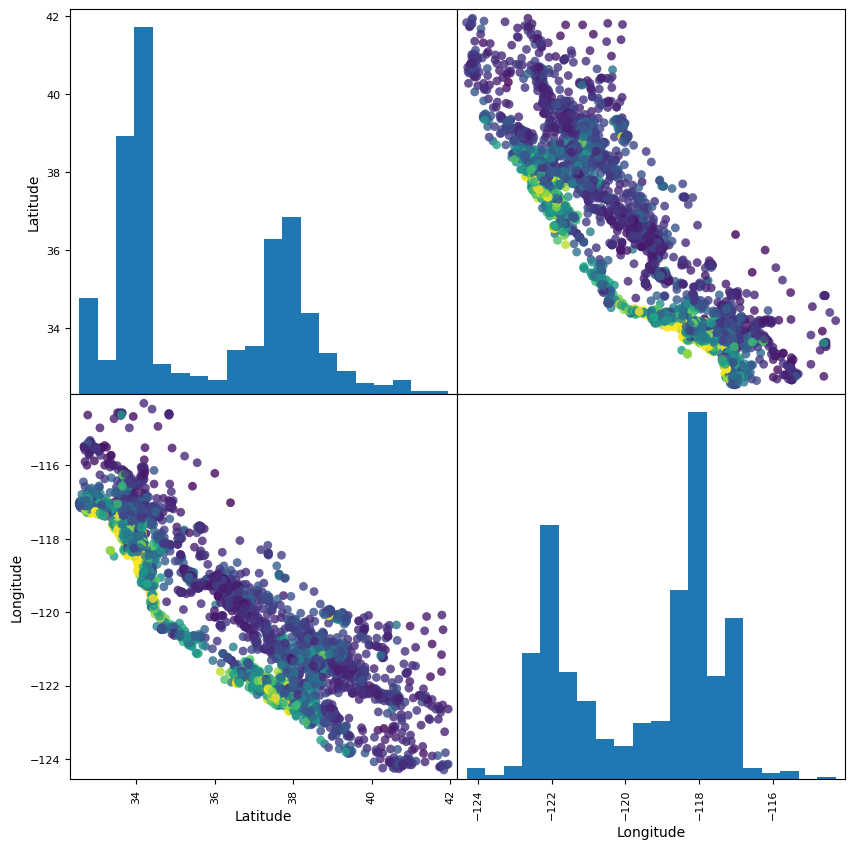

In [112]:
housing_df=pd.DataFrame(X_train, columns=housing.feature_names[6:8])
pd.plotting.scatter_matrix(housing_df, c=y_train, figsize=(10,10), marker='o',
                           hist_kwds={'bins': 20}, s=40, alpha=.8)
plt.show()

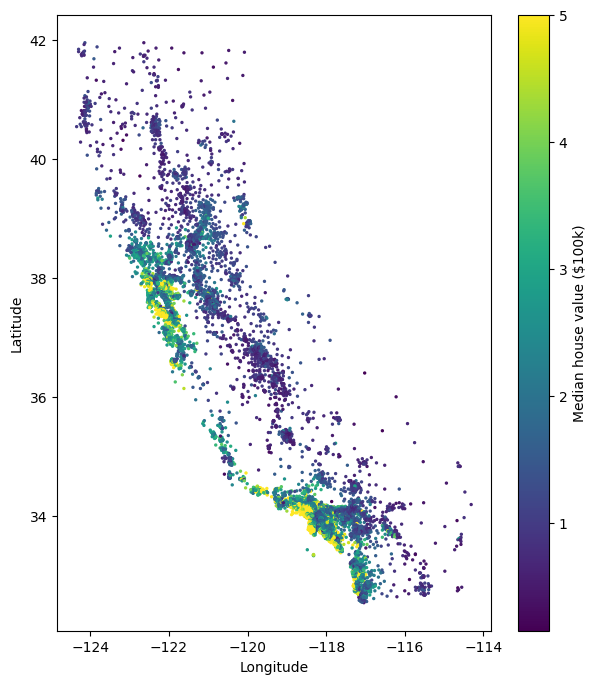

In [113]:
plt.figure(figsize=(7, 8))
plt.scatter(X[:, 1], X[:, 0], c=y, s=2, cmap="viridis")
plt.colorbar(label="Median house value ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [114]:
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train, y_train)               

y_pred = knn.predict(X_test)


In [115]:
from sklearn.metrics import mean_absolute_error

print("Test R^2: {:.2f}".format(knn.score(X_test, y_test)))
print("Train R^2: {:.2f}".format(knn.score(X_train, y_train)))
print("MAE: {:.2f}".format(mean_absolute_error(y_test, y_pred))) 

Test R^2: 0.70
Train R^2: 0.91
MAE: 0.38
